# 09 · A spectral change indicator with explicit confounders

Compare same-tile Sentinel-2A C1 L2A observations from August 2020 and August 2021 near Lake Almanor. Show common valid coverage and threshold sensitivity instead of presenting a spectral difference as confirmed forest loss.

[Notebook index](README.md) · [Companion article](../docs/articles/vegetation-change.md) · [Data sources and licences](../docs/DATA_SOURCES.md)

Run every cell from top to bottom in the locked Python 3.12 environment. The first run downloads the required public data pack and checks its SHA-256. Generated artifacts remain in the ignored `outputs/` directory.

In [1]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython import get_ipython
from IPython.display import display

from geoai_portfolio.io import ensure_data

get_ipython().run_line_magic("matplotlib", "inline")
plt.rcParams.update(
    {
        "figure.dpi": 110,
        "figure.figsize": (10, 4),
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titleweight": "bold",
        "axes.labelsize": 9,
        "axes.titlesize": 11,
        "font.size": 10,
        "savefig.bbox": "tight",
    }
)
pd.set_option("display.precision", 4)

In [2]:
import rasterio

from geoai_portfolio.rasters import map_array, reflectance, require_same_grid, scene_ndvi

data = ensure_data("satellite")
provenance = json.loads((data / "provenance.json").read_text())
display(
    pd.DataFrame(
        [
            {
                key: scene[key]
                for key in [
                    "id",
                    "datetime",
                    "processing_baseline",
                    "sun_elevation",
                    "scene_cloud_percent",
                ]
            }
            for scene in provenance["sentinel"]
        ]
    )
)

,id,datetime,processing_baseline,sun_elevation,scene_cloud_percent
0,S2A_T10TFK_20200812T185701_L2A,2020-08-12T19:03:28.562000Z,05.00,60.6967,0.0023
1,S2A_T10TFK_20210827T185458_L2A,2021-08-27T19:03:24.370000Z,05.00,56.5974,2.6544


## Establish comparability before differencing

Both observations are Sentinel-2A, tile T10TFK, C1 L2A, processing baseline 05.00,
using the same UTM grid and native red/NIR 10 m bands. Saved metadata specifies scale
0.0001 and offset −0.1 for both reprocessed dates. Acquisition year alone would not
tell us the offset. SCL masks and physically invalid index inputs are applied per date,
then intersected. The acquisitions are 12 August 2020 and 27 August 2021: the 15-day
seasonal difference, atmosphere/smoke, illumination and water status remain confounders.
Scene-wide cloud percentage does not guarantee a clear local crop.

In [3]:
before = scene_ndvi(data / "before.tif", data / "before-scl.tif")
after = scene_ndvi(data / "after.tif", data / "after-scl.tif")
with rasterio.open(data / "before.tif") as a, rasterio.open(data / "after.tif") as b:
    require_same_grid(a, b)
    pixel_area = abs(a.transform.a * a.transform.e - a.transform.b * a.transform.d)
common_mask = np.ma.getmaskarray(before) | np.ma.getmaskarray(after)
before_common = np.ma.array(before.data, mask=common_mask)
after_common = np.ma.array(after.data, mask=common_mask)
delta = after_common - before_common
display(
    pd.DataFrame(
        {
            "coverage": ["before valid", "after valid", "common valid", "excluded union"],
            "pixels": [before.count(), after.count(), delta.count(), common_mask.sum()],
        }
    )
)

,coverage,pixels
0,before valid,261429
1,after valid,236164
2,common valid,235606
3,excluded union,26538


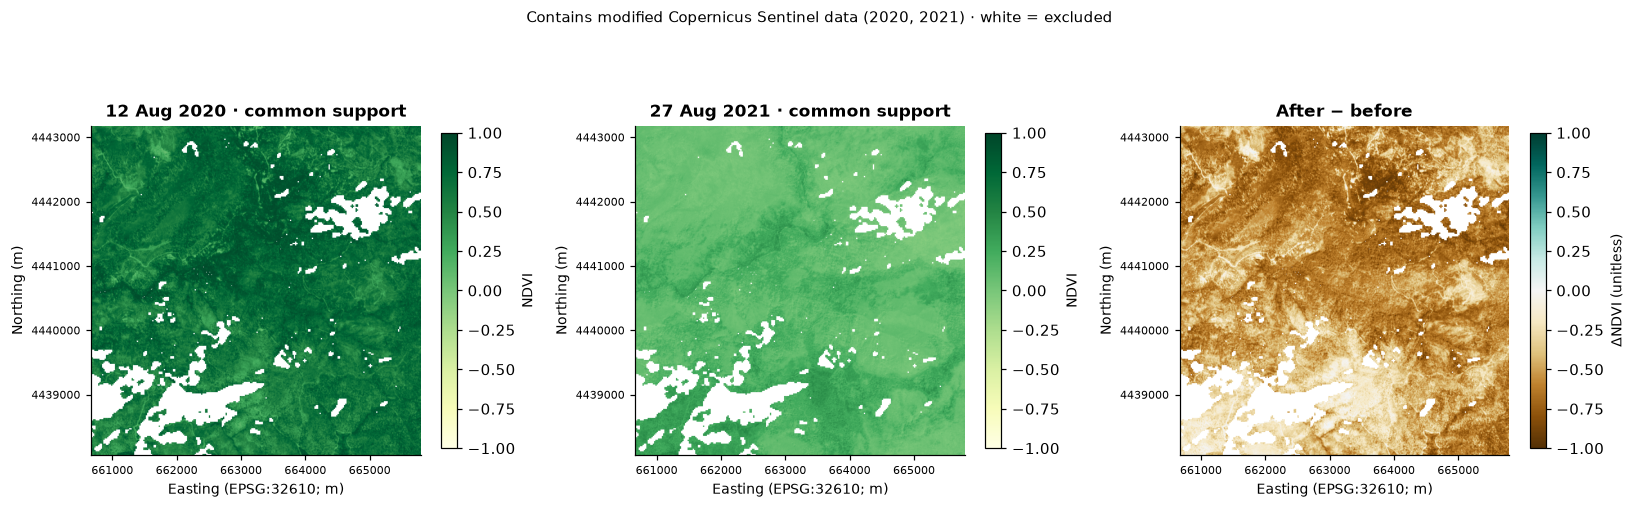

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
with rasterio.open(data / "before.tif") as source:
    for ax, values, title in zip(
        axes[:2],
        [before_common, after_common],
        ["12 Aug 2020 · common support", "27 Aug 2021 · common support"],
    ):
        image = map_array(ax, values, source, title, "YlGn", -1, 1)
        fig.colorbar(image, ax=ax, label="NDVI", shrink=0.65)
    image = map_array(axes[2], delta, source, "After − before", "BrBG", -1, 1)
    fig.colorbar(image, ax=axes[2], label="ΔNDVI (unitless)", shrink=0.65)
fig.suptitle(
    "Contains modified Copernicus Sentinel data (2020, 2021) · white = excluded", fontsize=10
)
plt.tight_layout()
plt.show()

## Inspect RGB and threshold sensitivity

Use the same reflectance-to-display stretch on both dates. The candidate area below
uses ΔNDVI thresholds −0.2, −0.3 and −0.4 and requires initial NDVI above 0.4.
The hectare totals are mapped indicator area on common valid support. They are not
error-adjusted forest-loss estimates, and there is no reference sample for accuracy.

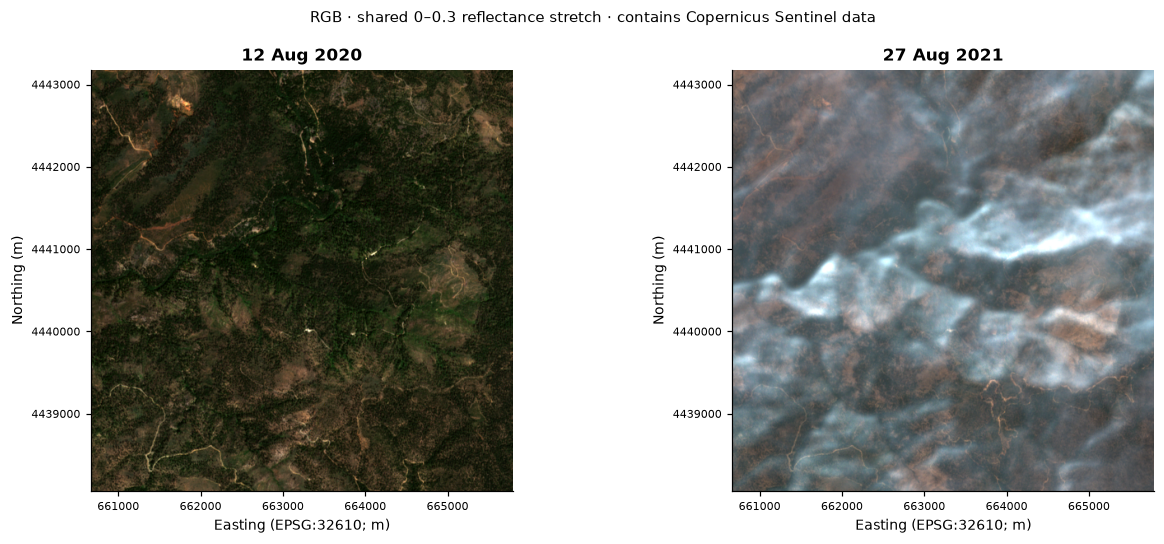

,delta_threshold,candidate_ha,common_valid_ha
0,-0.2,2163.35,2356.06
1,-0.3,2018.02,2356.06
2,-0.4,1756.68,2356.06


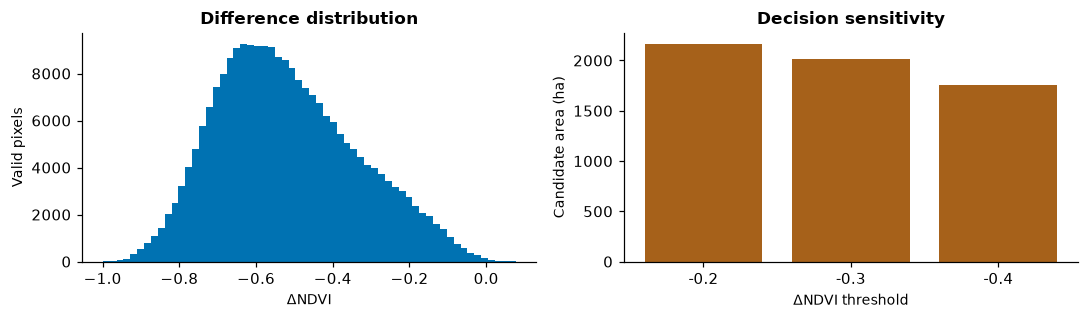

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, name, title in zip(axes, ["before", "after"], ["12 Aug 2020", "27 Aug 2021"]):
    with rasterio.open(data / f"{name}.tif") as source:
        rgb = np.stack([reflectance(source, band).filled(0) for band in [1, 2, 3]], axis=-1)
        map_array(ax, np.clip(rgb / 0.3, 0, 1), source, title)
fig.suptitle(
    "RGB · shared 0–0.3 reflectance stretch · contains Copernicus Sentinel data", fontsize=10
)
plt.tight_layout()
plt.show()
sensitivity = pd.DataFrame(
    [
        {
            "delta_threshold": threshold,
            "candidate_ha": float(((delta < threshold) & (before_common > 0.4)).sum())
            * pixel_area
            / 10000,
            "common_valid_ha": delta.count() * pixel_area / 10000,
        }
        for threshold in [-0.2, -0.3, -0.4]
    ]
)
display(sensitivity)
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].hist(delta.compressed(), bins=60, color="#0072B2")
axes[0].set(xlabel="ΔNDVI", ylabel="Valid pixels", title="Difference distribution")
axes[1].bar(sensitivity.delta_threshold.astype(str), sensitivity.candidate_ha, color="#A6611A")
axes[1].set(xlabel="ΔNDVI threshold", ylabel="Candidate area (ha)", title="Decision sensitivity")
plt.tight_layout()
plt.show()

## Supported interpretation

Large negative differences indicate reduced greenness on comparable valid pixels.
Attribution to fire, clearing, drought or phenology needs independent event evidence,
more observations, and reference sampling. Excluded pixels remain unknown. WorldCover
is not used to turn the indicator into a validated loss label. A longer same-season
time series and a stratified independent reference sample would be the next steps.